In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing, decomposition
from sklearn.decomposition import KernelPCA
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

data = np.load('../Data/spec4000_corrected.npz')
wavelengths = data['wavelengths']
X = data['X']
y = data['y']
labels = data['labels'].astype(str)

print("Data shape:", X.shape)

Data shape: (4000, 1000)


In [13]:
scaler = preprocessing.StandardScaler()
Xn = scaler.fit_transform(X)

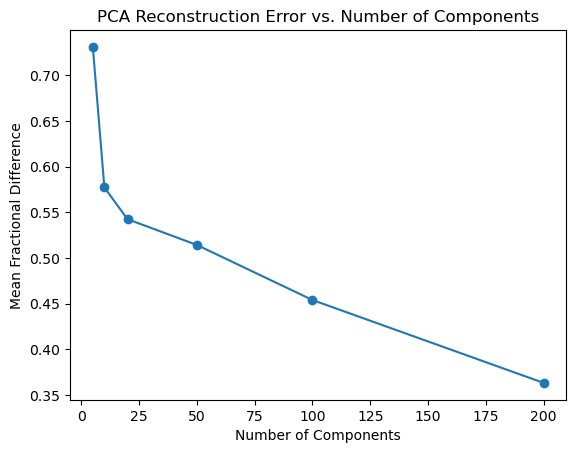

In [14]:
components = [5, 10, 20, 50, 100, 200]
reconstruction_errors = []

for n in components:
    pca = decomposition.PCA(n_components=n, random_state=0)
    X_proj = pca.fit_transform(Xn)
    X_rec = pca.inverse_transform(X_proj)

    frac_diff = np.mean(np.abs((X_rec - Xn) / Xn))
    reconstruction_errors.append(frac_diff)

plt.plot(components, reconstruction_errors, 'o-')
plt.xlabel("Number of Components")
plt.ylabel("Mean Fractional Difference")
plt.title("PCA Reconstruction Error vs. Number of Components")
plt.show()


In [15]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, mean_squared_error

def reconstruction_error(estimator, X):
    X_kpca = estimator.named_steps['kpca'].fit_transform(X)
    X_krec = estimator.named_steps['kpca'].inverse_transform(X_kpca)
    return -mean_squared_error(X, X_krec)

kpca = KernelPCA(kernel='rbf', n_components=10, fit_inverse_transform=True)

pipe = Pipeline([
    ('scaler', preprocessing.StandardScaler()),
    ('kpca', kpca)
])

param_grid = {'kpca__gamma': np.logspace(-3, 1, 5)}

search = GridSearchCV(pipe, param_grid, scoring=reconstruction_error, cv=3)
search.fit(X)

print("Best gamma:", search.best_params_['kpca__gamma'])
print("Best score (negative MSE):", search.best_score_)

Best gamma: 10.0
Best score (negative MSE): -212.9459025065104


In [16]:
best_gamma = search.best_params_['kpca__gamma']

for n in [10, 50]:
    kpca = KernelPCA(kernel='rbf', n_components=n, gamma=best_gamma, fit_inverse_transform=True)
    X_kpca = kpca.fit_transform(Xn)
    X_krec = kpca.inverse_transform(X_kpca)
    frac_diff = np.mean(np.abs((X_krec - Xn) / Xn))
    print(f"{n} components → Kernel PCA fractional difference: {frac_diff:.3f}")

10 components → Kernel PCA fractional difference: 1.258
50 components → Kernel PCA fractional difference: 1.823


>For 10 components, the results are better than what we obtained for PCA. The results are worse for the 50 components than for the 10 components. 